In [7]:
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt

gdf = gpd.read_file("C:/Users/isabe/Downloads/testingg.json")
gdf.to_file("ligeia_west_coastline_short.geojson", driver="GeoJSON")

In [8]:
lake = gdf

9


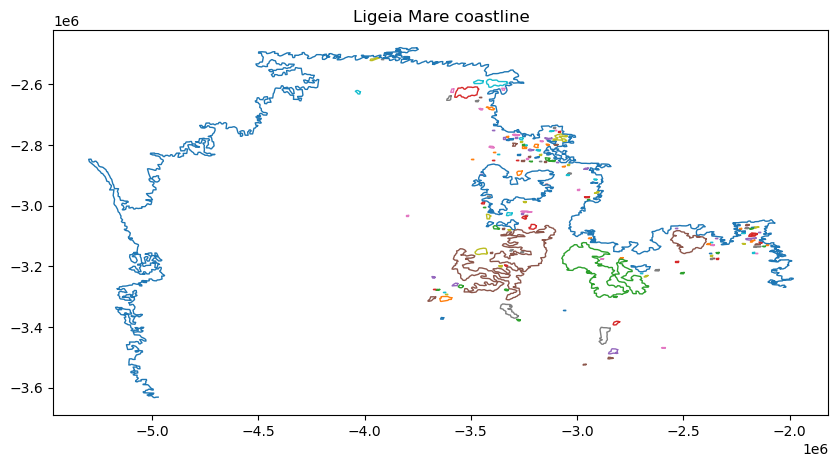

In [9]:
geom = lake.geometry.iloc[0]

# collect all coords first
all_x = []
all_y = []

for geom in gdf.geometry:
    coords = np.array(geom.coords)
    all_x.extend(coords[:, 0])
    all_y.extend(coords[:, 1])

all_x = np.array(all_x)
all_y = np.array(all_y)

# calculate stretch factor to match ArcGIS-looking proportions
x_range = all_x.max() - all_x.min()
y_range = all_y.max() - all_y.min()

stretch = 9
print(stretch)
plt.figure(figsize=(10, 5))

for geom in gdf.geometry:
    coords = np.array(geom.coords)
    x = coords[:, 0]
    y = coords[:, 1]

    # center and stretch vertically
    x_plot = x
    y_plot = (y - all_y.mean()) * stretch + all_y.mean()

    plt.plot(-y_plot, x_plot, linewidth=1)


plt.title("Ligeia Mare coastline")
plt.show()


Longest index: 160
Length: 6708516.33332567


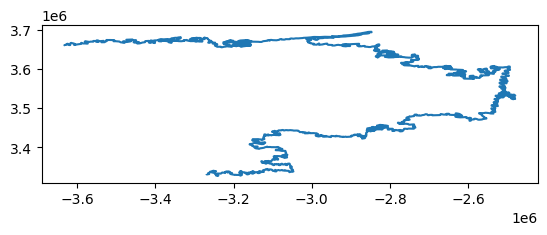

In [10]:
# find the longest geometry
longest_index = gdf.geometry.length.idxmax()

# extract it as a new GeoDataFrame
longest_coastline = gdf.loc[[longest_index]].copy()

# check it
print("Longest index:", longest_index)
print("Length:", longest_coastline.geometry.length.iloc[0])

longest_coastline.plot()
plt.show()

# save it
longest_coastline.to_file("ligeia_longest_coastline.geojson", driver="GeoJSON")

9


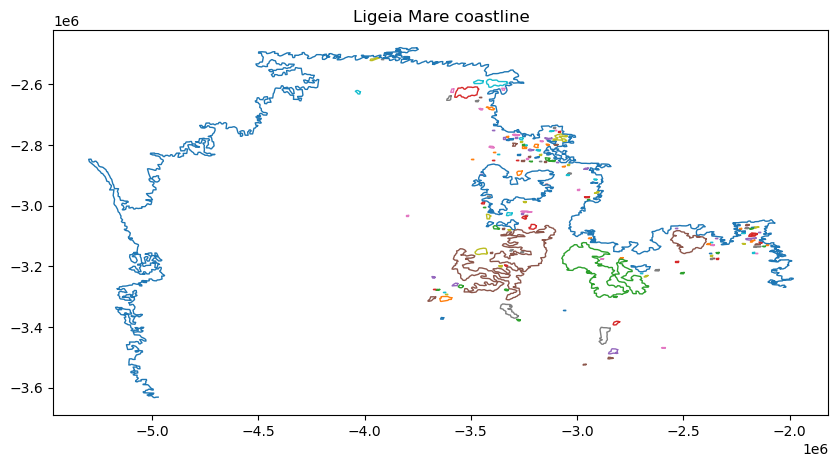

In [11]:
newlake = longest_coastline
geom = newlake.geometry.iloc[0]

# collect all coords at once
all_coords = np.vstack([np.array(g.coords) for g in gdf.geometry])
all_x, all_y = all_coords[:, 0], all_coords[:, 1]

stretch = 9
print(stretch)

plt.figure(figsize=(10, 5))

y_mean = all_y.mean()

for g in gdf.geometry:
    coords = np.array(g.coords)
    x, y = coords[:, 0], coords[:, 1]

    y_plot = (y - y_mean) * stretch + y_mean
    plt.plot(-y_plot, x, linewidth=1)

plt.title("Ligeia Mare coastline")
plt.show()

In [12]:
from shapely.geometry import LineString

stretch = 9

# compute global mean (same as your code)
all_coords = np.vstack([np.array(g.coords) for g in gdf.geometry])
y_mean = all_coords[:, 1].mean()

def transform_geom(geom):
    coords = np.array(geom.coords)
    x, y = coords[:, 0], coords[:, 1]

    # stretch + rotate (same math as before)
    y_stretched = (y - y_mean) * stretch + y_mean
    x_new = -y_stretched
    y_new = x

    return LineString(np.column_stack([x_new, y_new]))

# apply transformation
gdf_transformed = gdf.copy()
gdf_transformed["geometry"] = gdf.geometry.apply(transform_geom)

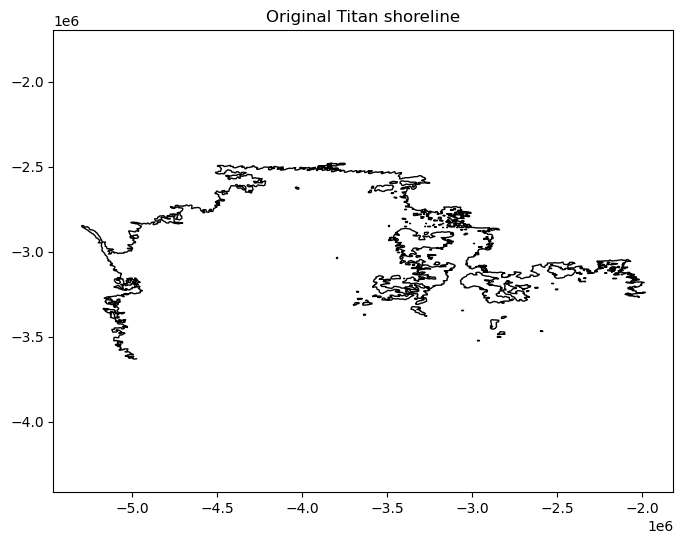

In [15]:
gdf_transformed.plot(figsize=(8, 6), color="black", linewidth=1)
plt.title("Original Titan shoreline")
plt.axis("equal")
plt.show()

In [17]:
# ensure closed loop
if x[0] != x[-1] or y[0] != y[-1]:
    x = np.append(x, x[0])
    y = np.append(y, y[0])

In [23]:
def roughness(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    perimeter = np.sum(np.sqrt(dx**2 + dy**2))

    # approximate area (shoelace formula)
    area = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    return perimeter / np.sqrt(area)

In [24]:
r_titan = roughness(x_titan, y_titan)
print(r_titan)

NameError: name 'x_titan' is not defined